Content analysis: Analyze the content of social media data to determine
what topics are being given data set using topic modelling

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from gensim import corpora
from gensim.models import LdaModel

import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

In [3]:
df = pd.read_csv("car_showroom_dataset.csv")

In [4]:
print(df.head())

   car_id     brand   model  price_lakh fuel_type  mileage_kmpl       city  \
0       1  Mahindra   Swift       22.02  Electric         26.40    Chennai   
1       2       BMW    City       51.55    Hybrid         23.28       Pune   
2       3       Kia     i20       67.09    Hybrid         12.60    Chennai   
3       4     Honda  XUV700        5.40    Diesel         25.20  Ahmedabad   
4       5   Hyundai   Nexon       43.24    Diesel         24.59      Delhi   

   sales_person_rating                       customer_review  
0                  4.4            Amazing experience overall  
1                  4.7                   Value for money car  
2                  3.2  Could be better in terms of features  
3                  4.9            Not satisfied with service  
4                  2.9                   Value for money car  


In [5]:
df['customer_review']

0                 Amazing experience overall
1                        Value for money car
2       Could be better in terms of features
3                 Not satisfied with service
4                        Value for money car
                        ...                 
1995              Amazing experience overall
1996    Could be better in terms of features
1997                     Value for money car
1998      Great performance and smooth drive
1999    Could be better in terms of features
Name: customer_review, Length: 2000, dtype: object

In [10]:
# remove nulls
df = df.dropna(subset=['customer_review'])

# remove duplicates
df = df.drop_duplicates()

In [11]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in stop_words]

processed = df['customer_review'].apply(preprocess)

In [9]:
# create dictionary
dictionary = corpora.Dictionary(processed)
# create corpus
corpus = [dictionary.doc2bow(text) for text in processed]

In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=3,
    passes=10
)

In [22]:
topics = lda_model.print_topics()

for topic in topics:
    print(topic)

(0, '0.104*"terms" + 0.104*"could" + 0.104*"better" + 0.103*"features" + 0.102*"satisfied" + 0.102*"service" + 0.094*"smooth" + 0.094*"performance" + 0.094*"great" + 0.094*"drive"')
(1, '0.150*"money" + 0.150*"value" + 0.150*"car" + 0.137*"mileage" + 0.137*"high" + 0.137*"decent" + 0.137*"price" + 0.001*"overall" + 0.001*"amazing" + 0.001*"experience"')
(2, '0.172*"features" + 0.170*"comfort" + 0.170*"excellent" + 0.161*"experience" + 0.161*"amazing" + 0.161*"overall" + 0.001*"mileage" + 0.001*"price" + 0.001*"decent" + 0.001*"high"')


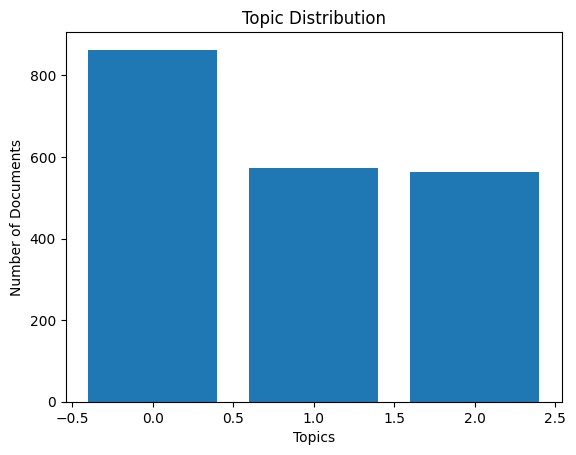

In [ ]:
topic_counts = [0]*3

for doc in corpus:
    topic_probs = lda_model.get_document_topics(doc)
    top_topic = max(topic_probs, key=lambda x: x[1])[0]
    topic_counts[top_topic] += 1

plt.bar(range(3), topic_counts)
plt.xlabel("Topics")
plt.ylabel("Number of Documents")
plt.title("Topic Distribution")
plt.show()